In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
import numpy as np

np.random.seed(42)

idx = np.random.choice(len(x_train), 10000, replace=False)

x_train = x_train[idx]
y_train = y_train[idx]

idx_test = np.random.choice(len(x_test), 2000, replace=False)

x_test = x_test[idx_test]
y_test = y_test[idx_test]

print(x_train.shape, x_test.shape)

(10000, 32, 32, 3) (2000, 32, 32, 3)


In [4]:
IMG_SIZE = 224

base = keras.applications.VGG16(include_top=False, weights="imagenet",
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))

inp = keras.Input((32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inp)
x = keras.applications.vgg16.preprocess_input(x)
out = layers.Flatten()(base(x, training=False))
extractor = keras.Model(inp, out)

train_feats = extractor.predict(x_train, batch_size=128).astype("float32")
test_feats  = extractor.predict(x_test,  batch_size=128).astype("float32")
print(train_feats.shape)   

I0000 00:00:1791103366.099896     677 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791103366.103983     677 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
2026-10-04 08:43:00.156369: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=1,k3=0} for conv (f32[128,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},

79/79 ━━━━━━━━━━━━━━━━━━━━ 107s 790ms/step
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step

2026-10-04 08:44:52.252784: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[80,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[80,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-10-04 08:44:52.252899: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.000210964s
Trying algorithm eng12{k11=2} for conv (f32[80,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[80,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convB

16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step 
(10000, 25088)


In [5]:
norm = layers.Normalization()
norm.adapt(train_feats)

head = keras.Sequential([
    keras.Input((train_feats.shape[1],)),
    norm,
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

head.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = head.fit(
    train_feats,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.3872 - loss: 1.9648 - val_accuracy: 0.6390 - val_loss: 1.1137
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6976 - loss: 0.9090 - val_accuracy: 0.7290 - val_loss: 0.8518
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7887 - loss: 0.6277 - val_accuracy: 0.7630 - val_loss: 0.7467
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8429 - loss: 0.4691 - val_accuracy: 0.7790 - val_loss: 0.6888
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8830 - loss: 0.3671 - val_accuracy: 0.7860 - val_loss: 0.6568
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9082 - loss: 0.2943 - val_accuracy: 0.7940 - val_loss: 0.6315
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9314 - loss: 0.2333 - val_accuracy: 0.7980 - val_loss: 0.6112
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9482 - loss: 0.1982 - val_accuracy: 0.8000 - v

In [12]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
test_loss, test_acc = head.evaluate(test_feats, y_test)
print("Test accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8305 - loss: 0.5463
Test accuracy: 0.8305000066757202


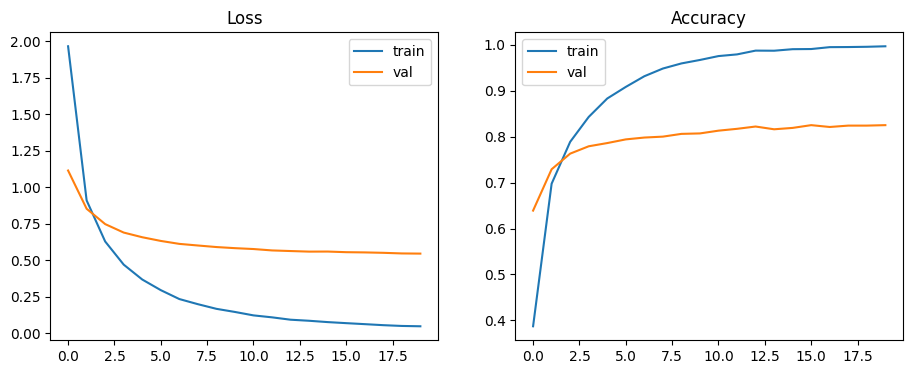

In [8]:

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.show()

In [9]:
#                                            For Resnet 

In [15]:
IMG_SIZE = 224

base = keras.applications.ResNet50(include_top=False, weights="imagenet",
                                input_shape=(IMG_SIZE, IMG_SIZE, 3))

inp = keras.Input((32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inp)
x = keras.applications.resnet50.preprocess_input(x)
out = layers.Flatten()(base(x, training=False))
extractor = keras.Model(inp, out)

train_feats_rest = extractor.predict(x_train, batch_size=128).astype("float32")
test_feats_rest  = extractor.predict(x_test,  batch_size=128).astype("float32")
print(train_feats_rest.shape)   

79/79 ━━━━━━━━━━━━━━━━━━━━ 39s 449ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 543ms/step
(10000, 100352)


In [17]:
norm = layers.Normalization()
norm.adapt(train_feats_rest)

head_rest = keras.Sequential([
    keras.Input((train_feats_rest.shape[1],)),
    norm,
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

head_rest.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_rest = head_rest.fit(
    train_feats_rest,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=256
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6992 - loss: 0.9943 - val_accuracy: 0.8540 - val_loss: 0.4479
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9351 - loss: 0.1942 - val_accuracy: 0.8670 - val_loss: 0.4106
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9784 - loss: 0.0770 - val_accuracy: 0.8720 - val_loss: 0.3997
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9926 - loss: 0.0409 - val_accuracy: 0.8650 - val_loss: 0.3993
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9970 - loss: 0.0267 - val_accuracy: 0.8710 - val_loss: 0.3910
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9982 - loss: 0.0191 - val_accuracy: 0.8730 - val_loss: 0.3921
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9994 - loss: 0.0134 - val_accuracy: 0.8740 - val_loss: 0.3866
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9996 - loss: 0.0108 - val_accuracy: 0.8780 - 

In [18]:
test_loss, test_acc = head_rest.evaluate(test_feats_rest, y_test)
print("Test accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8865 - loss: 0.4244
Test accuracy: 0.8865000009536743


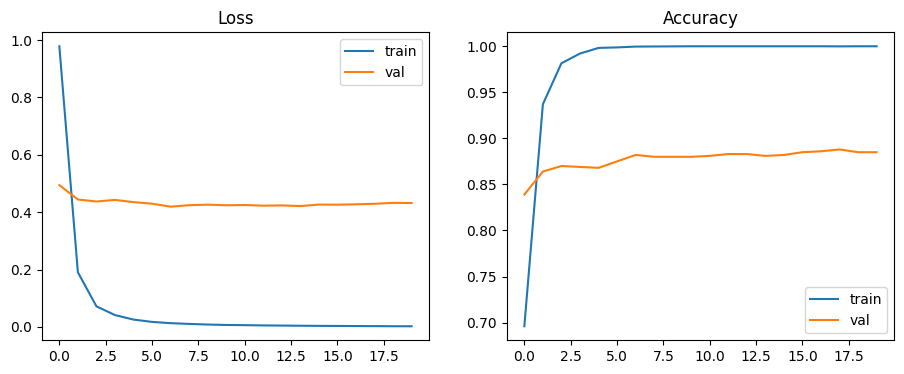

In [19]:

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.show()

In [20]:
#                     Compair VGG16 and Resnet 


In [22]:
vgg_test_loss, vgg_test_acc = head.evaluate(
    test_feats, y_test
)

res_test_loss, res_test_acc = head_rest.evaluate(
    test_feats_rest, y_test
)

print("VGG16 Accuracy:", vgg_test_acc)
print("ResNet50 Accuracy:", res_test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8530 - loss: 0.4747
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8865 - loss: 0.4244
VGG16 Accuracy: 0.8529999852180481
ResNet50 Accuracy: 0.8865000009536743


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8530 - loss: 0.4747
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8865 - loss: 0.4244
VGG16 Accuracy: 0.8529999852180481
ResNet50 Accuracy: 0.8865000009536743


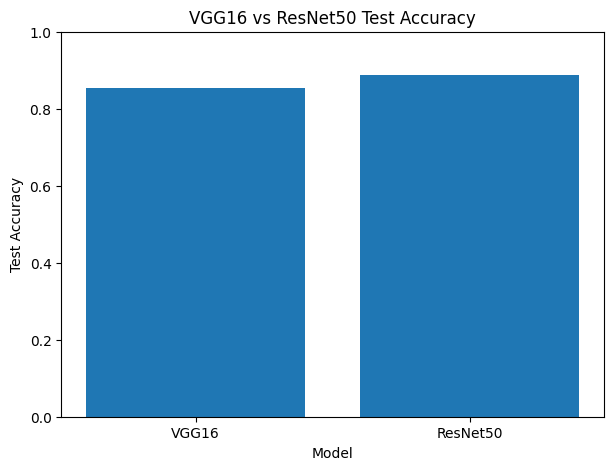

In [23]:
vgg_test_loss, vgg_test_acc = head.evaluate(test_feats, y_test)

res_test_loss, res_test_acc = head_rest.evaluate(
    test_feats_rest, y_test
)

print("VGG16 Accuracy:", vgg_test_acc)
print("ResNet50 Accuracy:", res_test_acc)

# Plot comparison
import matplotlib.pyplot as plt

models = ["VGG16", "ResNet50"]
accuracies = [vgg_test_acc, res_test_acc]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.title("VGG16 vs ResNet50 Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.show()